In [12]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.3477116)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

#-------------------------------
# DUSTY FSPS SPECTRUM
#-------------------------------
sp = fsps.StellarPopulation(zcontinuous=3, sfh=3, add_neb_emission=False, add_neb_continuum=False)

In [13]:
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)
wave, spec_fsps_dustfree= sp.get_spectrum(tage=13.8) 

# FSPS Dustfree

In [14]:
diffdust = 2
diffdust_index = -0.7
young_dust = 0
young_dust_index = -1

sp.params['dust2'] = 0
sp.params['dust1'] = 0
sp.params['dust_index'] = 1
sp.params['dust1_index'] = 1

wave, spec_fsps_dustfree= sp.get_spectrum(tage=13.8) 
print(sp.dust_mass)

0.0


# FSPS Diffuse Dust

In [15]:

sp.params['dust1'] = young_dust
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = False
sp.params['dust_type'] = 4

wave, spec_fsps_diffuse = sp.get_spectrum(tage=13.8) 
print('FSPS with \ndust1:', sp.params['dust1'], '\ndust2:', sp.params['dust2'], '\ndust1_index:', sp.params['dust1_index'], '\ndust_index:', sp.params['dust_index'])

FSPS with 
dust1: 0.0 
dust2: 2 
dust1_index: -1 
dust_index: -0.7


# FSPS with Dust Emission

In [16]:
sp.params['add_dust_emission'] = True
sp.params['duste_umin'] = 1.0
sp.params['duste_qpah'] = 3.5
sp.params['duste_gamma'] = 1

wave, spec_fsps_hot_dust_emi = sp.get_spectrum(tage=13.8)


sp.params['add_dust_emission'] = True
sp.params['duste_umin'] = 1.0
sp.params['duste_qpah'] = 3.5
sp.params['duste_gamma'] = 0

wave, spec_fsps_cold_dust_emi = sp.get_spectrum(tage=13.8)

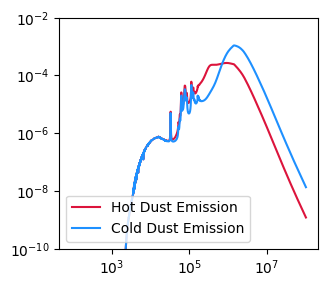

In [17]:
plt.figure(figsize = (10/3,3))
plt.loglog(wave, spec_fsps_hot_dust_emi, color = 'crimson', label='Hot Dust Emission')
plt.loglog(wave, spec_fsps_cold_dust_emi, color = 'dodgerblue', label='Cold Dust Emission')
plt.ylim(1e-10, 1e-2)
plt.legend()

# CSP 

In [18]:
dust_params = {'tau_pow': young_dust,
                'alpha': -young_dust_index, 'tau_kc': 0.0, 'dust_index': 0.0,
                'diffuse_params': {'tau_kc': diffdust, 'dust_index': diffdust_index}}

emi_params = {'duste_qpah': 0.5, 
              'duste_umin': 1.0, 
              'duste_gamma': 0.01}

from jax import jit
def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)

# --- Compile the function, marking `csp` as static
run_spectrum_jit = jit(run_spectrum, static_argnums=0)

#-------------------------------
# CSP SPECTRUM WITH DUST
#-------------------------------
csp_diff = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = False, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)


theta = jnp.array(csp_diff.theta_init.at[csp_diff.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp_diff.diffuse_tau_kc_idx].set(diffdust))

spec_diffuse = run_spectrum_jit(csp_diff, theta)

theta = jnp.array(theta.at[csp_diff.diffuse_dust_index_idx].set(0))
theta = jnp.array(theta.at[csp_diff.diffuse_tau_kc_idx].set(0))

spec_dustfree = run_spectrum_jit(csp_diff, theta)

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Parameters registered: ['lookback_time', 'sfh', 'zh', 'diffuse_tau_kc', 'diffuse_dust_index']


Get spectrum with dust attenuation only and no nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'zh_idx'])


# Compare to FSPS

In [ ]:
#----------------------------
# FSPS no dust
#----------------------------

sp.params['dust1'] = 0
sp.params['dust2'] = 0
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = False
sp.params['dust_type'] = 4

wave, spec_fsps_nodust = sp.get_spectrum(tage=13.8) 


#----------------------------
# FSPS diffuse dust
#----------------------------

sp.params['dust1'] = 0
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index


wave, spec_fsps_diff_dust = sp.get_spectrum(tage=13.8) 


#----------------------------
# FSPS diffuse and young dust
#----------------------------

sp.params['dust1'] = young_dust
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index


wave, spec_fsps_dusty = sp.get_spectrum(tage=13.8) 

#----------------------------
# FSPS only young dust
#----------------------------

sp.params['dust1'] = young_dust
sp.params['dust2'] = 0
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index


wave, spec_fsps_young_dust = sp.get_spectrum(tage=13.8) 

# Compare Dustfree

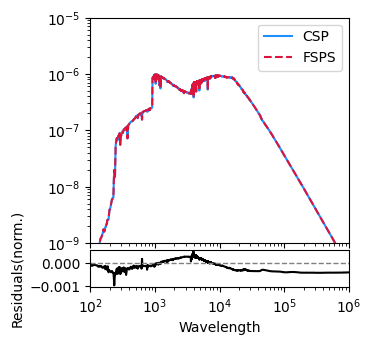

In [19]:
# Compute normalized residuals
residuals = (spec_dustfree - spec_fsps_dustfree) / spec_fsps_dustfree

# Create subplots
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10/3, 3.5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 0.5], 'hspace': 0.05})

ax0.loglog(wave, spec_dustfree, color='dodgerblue', label='CSP')
ax0.loglog(wave, spec_fsps_dustfree, color='crimson', linestyle='dashed', label='FSPS')
ax0.set_ylim(1e-9, 1e-5)
ax0.set_xlim(1e2, 1e6)
ax0.legend()

ax1.plot(wave, residuals, color='black')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_xlabel('Wavelength')
ax1.set_ylabel('Residuals(norm.)')
ax1.set_yscale('linear')

# Compare Dust Attenuation

/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_18856/737656043.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


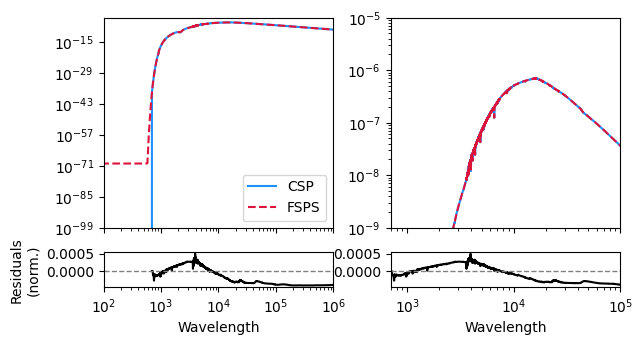

In [20]:
residuals = (spec_diffuse - spec_fsps_diffuse) / spec_fsps_diffuse

fig, axs = plt.subplots(2, 2, figsize=(20/3, 3.5), sharex='col',
                        gridspec_kw={'height_ratios': [3, 0.5], 'hspace': 0.2, 'wspace': 0.25})

ax0_left, ax1_left = axs[0, 0], axs[1, 0]
ax0_left.loglog(wave, spec_diffuse, color='dodgerblue', label='CSP')
ax0_left.loglog(wave, spec_fsps_diffuse, color='crimson', linestyle='dashed', label='FSPS')
ax0_left.set_ylim(1e-99, 1e-4)
ax0_left.set_xlim(1e2, 1e6)
ax0_left.legend()

ax1_left.plot(wave, residuals, color='black')
ax1_left.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1_left.set_xlabel('Wavelength')
ax1_left.set_ylabel('Residuals\n(norm.)')

ax0_right, ax1_right = axs[0, 1], axs[1, 1]
ax0_right.loglog(wave, spec_diffuse, color='dodgerblue', label='CSP')
ax0_right.loglog(wave, spec_fsps_diffuse, color='crimson', linestyle='dashed', label='FSPS')
ax0_right.set_ylim(1e-9, 1e-5)
ax0_right.set_xlim(7*1e2, 1e5)

ax1_right.plot(wave, residuals, color='black')
ax1_right.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1_right.set_xlabel('Wavelength')

plt.tight_layout()
plt.show()

# Get Attenuation Curve via Spectra

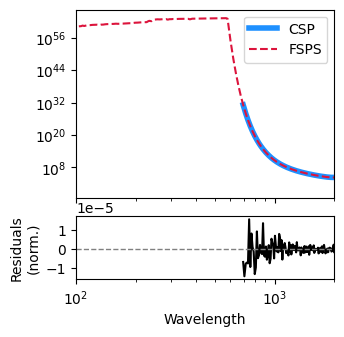

In [22]:
csp_ratio = spec_dustfree / spec_diffuse
fsps_ratio = spec_fsps_dustfree / spec_fsps_diffuse

residuals = csp_ratio / fsps_ratio - 1

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10/3, 3.5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.15})

ax0.loglog(wave, csp_ratio, lw=4, color='dodgerblue', label='CSP')
ax0.loglog(wave, fsps_ratio, color='crimson', linestyle='dashed', label='FSPS')
ax0.set_xlim(1e2, 2*1e3)
ax0.legend()
ax0.tick_params(labelbottom=False)

ax1.plot(wave, residuals, color='black')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_xlabel('Wavelength')
ax1.set_ylabel('Residuals\n(norm.)')


plt.show()

# Add Dust Emission - pure Python no JAX

## Read in Emission Grid

In [24]:
import numpy as np
from pathlib import Path

def read_dustem_files(sps_home, str_dustem, nqpah_dustem, ndim_dustem, spec_lambda, numin_dustem):
    # Allocate arrays
    dustem2_dustem = np.zeros((len(spec_lambda), nqpah_dustem, numin_dustem * 2))
    
    for sqpah in range(nqpah_dustem):

        # Build file path
        if sqpah == 10:
            filename = Path(sps_home) / 'dust' / 'dustem' / f"{str_dustem}_MW3.1_100.dat"
        else:
            filename = Path(sps_home) / 'dust' / 'dustem' / f"{str_dustem}_MW3.1_{sqpah}0.dat"
        print('filename:', filename)
        # Read file
        try:
            with open(filename, 'r') as f:
                lines = f.readlines()
        except FileNotFoundError:
            raise RuntimeError("SPS_SETUP ERROR: error opening dust emission file")
        
        # Skip 2 header lines
        data_lines = lines[2:2 + ndim_dustem]


        # Parse wavelength and dust emission spectrum
        lambda_dustem = np.zeros(ndim_dustem)
        dustem_dustem = np.zeros((ndim_dustem, numin_dustem * 2))
        
        for i, line in enumerate(data_lines):
            try:
                parts = list(map(float, line.strip().split()))
                lambda_dustem[i] = parts[0]
                dustem_dustem[i, :] = parts[1:]
            except Exception:
                raise RuntimeError("SPS_SETUP ERROR: error during dust emission read")
        
        # Convert wavelength from microns to Angstroms
        lambda_dustem *= 1e4

        # Interpolate dust spectrum to master wavelength grid
        for j in range(numin_dustem * 2):
            # Only interpolate for wavelengths >= 1 micron (1e4 Angstroms)
            mask = spec_lambda >= 1e4
            if np.any(mask):
                dustem2_dustem[mask, sqpah, j] = np.interp(
                    spec_lambda[mask], lambda_dustem, dustem_dustem[:, j]
                )

    return dustem2_dustem

dustem2_dustem = read_dustem_files('/Users/amanda/Prospector/fsps', str_dustem='dl07', nqpah_dustem=7, ndim_dustem=1001, spec_lambda=wave, 
                                   numin_dustem=22)

filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_00.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_10.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_20.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_30.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_40.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_50.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_60.dat


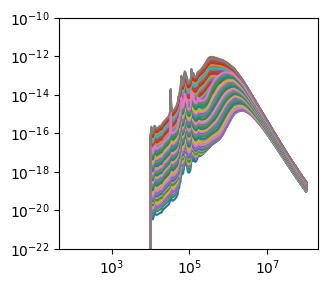

In [25]:
plt.figure(figsize = (10/3,3))
for sqpah in range(7):
    for j in range(44):
        plt.loglog(wave, dustem2_dustem[:, sqpah, j], label=f'PAH {sqpah}, j={j}')
    plt.ylim(1e-22, 1e-10)


# Add Dust Emission

In [ ]:
import jax.numpy as jnp
import jax

import numpy as np
from pathlib import Path

class DustEmission:

    def __init__(self, duste_model="DL07",
                 dust_file=None, spec_lambda=None, **kwargs):
        """
        Initialize the DustEmission object with parameters for dust emission modeling.

        Parameters
        ----------
        duste_model : str
            Dust emission model to use: 'DL07' or 'THEMIS'.
        dust_file : str
            Path to the dust emission file (required).
        spec_lambda : ndarray
            Wavelength grid over which dust emission will be evaluated (required).
        kwargs : dict
            Optional keyword arguments to override default dust parameters.
            Supported: duste_qpah, duste_umin, duste_gamma
        """

        # Store model choice (e.g., 'DL07' or 'THEMIS')
        self.duste_model = duste_model

        # Dust parameter values
        self.duste_qpah = None
        self.duste_umin = None
        self.duste_gamma = None

        # Model grid arrays for allowed values of qPAH and Umin
        self.qpaharr = None
        self.uminarr = None

        # Placeholder for loaded dust emission spectra
        self.dustem2_dustem = None

        # File path and wavelength grid
        self.dust_file = None
        self.spec_lambda = None

        # Store any additional keyword arguments for later use
        self.dwargs = kwargs

        # Read in key dust parameters, allowing overrides via kwargs
        self.duste_qpah = kwargs.pop("duste_qpah", 3.5)
        self.duste_umin = kwargs.pop("duste_umin", 1.0)
        self.duste_gamma = kwargs.pop("duste_gamma", 0.01)

        # Set parameter grids based on selected dust model
        if self.duste_model == "DL07":
            self.qpaharr = jnp.array([0.47,1.12,1.77,2.50,3.19,3.90,4.58])
            self.uminarr = jnp.array([0.1,0.15,0.2,0.3,0.4,0.5,0.7,0.8,1.0,1.2,1.5,
                                      2.0,2.5,3.0,4.0,5.0,7.0,8.0,12.0,15.0,20.0,25.0])
            self.nqpah_dustem = self.qpaharr.size
            self.numin_dustem = self.uminarr.size
        elif self.duste_model == "THEMIS":
            # THEMIS model uses smaller qPAH values rescaled to percent
            self.qpaharr = jnp.array([0.02, 0.06, 0.10, 0.14, 0.17, 0.20, 0.24,
                                      0.28, 0.32, 0.36, 0.40]) / 2.2 * 100
            self.uminarr = jnp.array([
                0.1, 0.12, 0.15, 0.17, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6,
                0.7, 0.8, 1.0, 1.2, 1.5, 1.7, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0,
                6.0, 7.0, 8.0, 10.0, 12.0, 15.0, 17.0, 20.0, 25.0, 30.0,
                35.0, 40.0, 50.0, 80.0
            ])
            self.nqpah_dustem = self.qpaharr.size
            self.numin_dustem = self.uminarr.size
        else:
            raise ValueError("Invalid duste_model. Choose 'DL07' or 'THEMIS'.")

        # Ensure that necessary data is provided
        if dust_file is None or spec_lambda is None:
            raise ValueError("If `duste=True`, both `dust_file` and `spec_lambda` must be provided.")

        self.dust_file = dust_file
        self.spec_lambda = spec_lambda

        # Load emission templates or model data from file
        self.load_dust_emission(dust_file, spec_lambda)
    
    def get_default_params(self):
        return DustEmiParams(duste_qpah=3.5, duste_umin=1.0, duste_gamma=0.0)

    def __repr__(self):
        """
        Custom string representation of the DustEmission object.
        Provides a readable summary of model settings and parameters.
        """

        def format_array(arr):
            """Helper to format short arrays inline; longer arrays multiline."""
            if arr is None:
                return "None"
            if arr.ndim == 1 and len(arr) <= 5:
                return f"[{', '.join(map(str, arr))}]"
            return f"\n    " + "\n    ".join(map(str, arr))

        attributes = {
            "Duste model": self.duste_model,
            "DUST qPAH": self.duste_qpah,
            "DUST Umin": self.duste_umin,
            "DUST Gamma": self.duste_gamma,
            f"qpaharr ({self.duste_model})": format_array(self.qpaharr),
            f"uminarr ({self.duste_model})": format_array(self.uminarr),
            "dust_file": self.dust_file,
            "spec_lambda": self.spec_lambda.shape if self.spec_lambda is not None else None,
        }

        if self.dwargs:
            attributes["Extra parameters (dwargs)"] = self.dwargs

        attr_str = "\n".join(f"  {k:<30}: {v}" for k, v in attributes.items() if v is not None)
        return f"\nDustEmission Model:\n{'='*50}\n{attr_str}\n{'='*50}"


    def load_dust_emission(self, dust_file=None, spec_lambda=None):
        
        # Use default paths if not provided
        if dust_file is None:
            dust_file = self.dust_file
        if spec_lambda is None:
            spec_lambda = self.spec_lambda

        # Select dust model parameters
        dust_model_params = {
            "DL07": (7, 1001, 22),
            "THEMIS": (11, 576, 37),
        }
        
        nqpah_dustem, ndim_dustem, numin_dustem = dust_model_params[self.duste_model]

        # Initialize storage for interpolated spectra (JAX-compatible)
        dustem2_dustem = np.zeros((len(spec_lambda), nqpah_dustem, numin_dustem * 2))

        # Read and interpolate dust emission spectra
        for k in range(nqpah_dustem):
            filename = Path(dust_file) / "dust" / "dustem" / f"{self.duste_model}_MW3.1_{'100' if k == 10 else f'{k}0'}.dat"

            if not filename.exists():
                raise FileNotFoundError(f"Error opening dust emission file: {filename}. File does not exist.")

            with filename.open('r') as f:
                next(f)  # Skip first header line
                next(f)  # Skip second header line

                lambda_dustem = np.zeros(ndim_dustem)
                dustem_dustem = np.zeros((ndim_dustem, numin_dustem * 2))

                for i in range(ndim_dustem):
                    try:
                        values = list(map(float, f.readline().strip().split()))
                        lambda_dustem[i], dustem_dustem[i, :] = values[0], values[1:]
                    except Exception:
                        raise RuntimeError(f"Error reading dust emission file: {filename}")

            # Convert wavelength from microns to Angstroms
            lambda_dustem *= 1E4

            # Interpolate dust spectra onto the master wavelength array
            jj = jnp.searchsorted(spec_lambda / 1E4, 1, side='left')
            for j in range(numin_dustem * 2):
                dustem2_dustem[jj:, k, j] = jnp.interp(spec_lambda[jj:], lambda_dustem, dustem_dustem[:, j])

        self.dustem2_dustem = jnp.array(dustem2_dustem)

    def update_dust_params(self, duste_qpah = 3.5, duste_umin = 1.0, duste_gamma = 0.01):
        """
        Update dust parameters for emission calculations.

        Parameters:
            duste_qpah (float, optional): New PAH fraction.
            duste_umin (float, optional): New minimum U radiation field.
            duste_gamma (float, optional): New fraction of high U component.
        """
        self.duste_qpah = duste_qpah
        self.duste_umin = duste_umin
        self.duste_gamma = duste_gamma

    def compute_dust_emission(self, spec_diffuse, spec_dustfree, spec_lambda, diffuse_curve,
                                        duste_qpah, duste_umin, duste_gamma):
        """
        Compute dust emission using JAX-optimized vectorization for GPU acceleration.

        Parameters:
            spec_diffuse (jnp.ndarray): Attenuated spectrum after dust absorption.
            spec_dustfree (jnp.ndarray): Stellar spectrum before attenuation.
            spec_lambda (jnp.ndarray): Wavelength array in Angstroms.
            duste_qpah (float, optional): PAH fraction. Defaults to self.duste_qpah if None.
            duste_umin (float, optional): Minimum U radiation field. Defaults to self.duste_umin if None.
            duste_gamma (float, optional): Fraction of high U component. Defaults to self.duste_gamma if None.

        Returns:
            tuple: (Updated spectrum with dust emission added, Estimated dust mass)
        """

        clight = const.c.value  # m/s
        tiny_number = 1e-70
        
        nu = clight * 1e10 / spec_lambda  # Hz

        # --- Compute Lbol before and after attenuation ---
        lbold = jnp.trapezoid(spec_diffuse, nu)
        lboln = jnp.trapezoid(spec_dustfree, nu)

        # --- QPAH interpolation setup ---
        qlo = jnp.clip(jnp.searchsorted(self.qpaharr, duste_qpah) - 1, 0, self.nqpah_dustem - 2)
        dq = (duste_qpah - self.qpaharr[qlo]) / (self.qpaharr[qlo + 1] - self.qpaharr[qlo])
        dq = jnp.clip(dq, 0.0, 1.0)

        # --- Umin interpolation setup ---
        ulo = jnp.clip(jnp.searchsorted(self.uminarr, duste_umin) - 1, 0, self.numin_dustem - 2)
        du = (duste_umin - self.uminarr[ulo]) / (self.uminarr[ulo + 1] - self.uminarr[ulo])
        du = jnp.clip(du, 0.0, 1.0)
    
        # --- gamma limiting ---
        gamma = jnp.clip(duste_gamma, 0.0, 1.0)

        # --- Bilinear interpolation ---
        dumin = (
            (1 - dq) * (1 - du) * self.dustem2_dustem[:, qlo, 2 * ulo] +
            dq * (1 - du) * self.dustem2_dustem[:, qlo + 1, 2 * ulo] +
            dq * du * self.dustem2_dustem[:, qlo + 1, 2 * (ulo + 1)] +
            (1 - dq) * du * self.dustem2_dustem[:, qlo, 2 * (ulo + 1)] 
        )

        dumax = (
            (1 - dq) * (1 - du) * self.dustem2_dustem[:, qlo, 2 * ulo + 1] +
            dq * (1 - du) * self.dustem2_dustem[:, qlo + 1, 2 * ulo + 1] +
            dq * du * self.dustem2_dustem[:, qlo + 1, 2 * (ulo + 1) + 1] +
            (1 - dq) * du * self.dustem2_dustem[:, qlo, 2 * (ulo + 1) + 1]
        )

        # Combine both parts of P(U)dU
        mduste = (1 - gamma) * dumin + gamma * dumax
        mduste = jnp.maximum(mduste, tiny_number)


        # Normalize the dust emission to match the absorbed luminosity
        labs = lboln - lbold
        norm = jnp.trapezoid(mduste, nu)
        duste = mduste / norm * labs
        self.duste = jnp.maximum(duste, tiny_number)


        # --- Two explicit self-absorption iterations ---
        # Iteration 1
        oduste_1 = duste
        duste_1 = duste * diffuse_curve
        tduste_1 = duste_1
        lbold_1 =jnp.trapezoid(duste_1, nu)
        lboln_1 =jnp.trapezoid(oduste_1, nu)
        duste_1 = jnp.maximum(mduste / norm * (lboln_1 - lbold_1), tiny_number)

        # Iteration 2
        oduste_2 = duste_1
        duste_2 = duste_1 * diffuse_curve
        tduste_2 = tduste_1 + duste_2
        lbold_2 =jnp.trapezoid(duste_2, nu)
        lboln_2 =jnp.trapezoid(oduste_2, nu)
        duste_2 = jnp.maximum(mduste / norm * (lboln_2 - lbold_2), tiny_number)

        # Final results
        specdust_final = spec_diffuse + tduste_2

        # Dust mass
        mdust = 3.21e-3 / (4 * jnp.pi) * labs / norm

        return specdust_final, mdust, tduste_2





In [37]:
csp = csp_diff

In [41]:
emi = DustEmission(spec_lambda=csp.wave, dust_file='/Users/amanda/Prospector/fsps')

specdust, mdust, tduste = emi.compute_dust_emission(spec_diffuse=spec_diffuse, spec_dustfree=spec_dustfree,
                                                        spec_lambda=csp.wave, diffuse_curve=spec_diffuse/spec_dustfree,
                                                        duste_qpah=3.5, duste_umin=1.0, duste_gamma=0.)

-3.1684318e-05


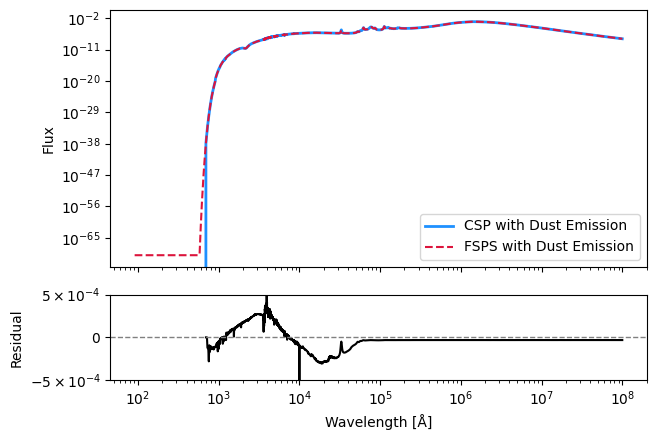

In [44]:

# Compute normalized residuals
residuals = (specdust - spec_fsps_cold_dust_emi) / spec_fsps_cold_dust_emi

# Create figure with two vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3, 4.5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Top panel: spectra
ax1.loglog(csp.wave, specdust, color='dodgerblue', lw = 2, label='CSP with Dust Emission')
ax1.loglog(csp.wave, spec_fsps_cold_dust_emi, ls = 'dashed', color='crimson', label='FSPS with Dust Emission')
#ax1.set_ylim(1e-10, 1e-2)

ax1.set_ylabel("Flux")
ax1.legend()

# Bottom panel: normalized residuals
ax2.plot(csp.wave, residuals, color='black')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.set_yscale('symlog')
ax2.set_ylabel("Residual")
ax2.set_xlabel("Wavelength [Å]")
ax2.set_ylim(-0.5*1e-3, 0.5*1e-3)

plt.tight_layout()
print(residuals[-1])